# 🎯 Objective

The goal of this assignment is to:

* implement **binary logistic regression** in PyTorch using only tensors,
* compute gradients for logistic regression **manually** (without using `.grad` for parameter updates),
* implement **gradient descent manually**,
* build and train an **MLP with 1 or 2 hidden layers**,
* understand binary classification with **sigmoid + binary cross-entropy**,
* work with an image dataset by **flattening images into vectors**.


---

## 📌 General Requirements

* Use **PyTorch**
* Submit a **Jupyter Notebook (.ipynb)**
* Notebook must:
  * run from top to bottom without errors,
  * include markdown explanations,
  * include plots where required,
  * set a random seed,
  * use clear variable names,
  * be reproducible.

You may use a dataset such as **Fashion-MNIST**
@[https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html](mention://dac22907-0ddd-428c-8ed2-30b69f15f97c/url/970c64e1-87da-4a39-9989-2cb94da80d34)


---

# ⚠ Restrictions (Important)

For the entire assignment:

✅ Allowed:

* `torch.Tensor` operations
* `torch.exp`, `torch.log`, `torch.matmul`, `@`
* indexing, masking, reshaping, flattening
* `torchvision.datasets` only for loading data
* plotting libraries such as `matplotlib`

❌ Not allowed in **Task 1**:

* `loss.backward()`
* `.grad` for computing logistic regression parameter updates
* `torch.optim.*`
* `torch.nn.Linear`
* high-level loss modules such as `nn.BCELoss`, `nn.BCEWithLogitsLoss`
* high-level training wrappers

❌ Not allowed in **all tasks**:

* `torch.optim.*`
* high-level training wrappers (Lightning, fastai, Trainer APIs)

⚠ For the MLP tasks, you may use autograd via `loss.backward()`, but you must still implement:

* the forward pass yourself,
* the parameter tensors yourself,
* the parameter updates manually.


---

# Dataset Construction for All Tasks

Use an image dataset such as **Fashion-MNIST**.

Each image should be treated as a vector:

$$
x \in \mathbb{R}^{784}
$$

by flattening the $28 \times 28$ image into a 1D vector.

## Binary Classification Setup

Choose **one class as the positive class** and treat all other classes as negative.

For example:

* positive class: **Pullover**,
* negative class: all other Fashion-MNIST classes.

To make the dataset balanced:


1. keep **all positive examples** of the chosen class,
2. randomly sample the **same number of negative examples** from the remaining classes,
3. combine them into one binary dataset.

Thus the labels are:

$$
y =
\begin{cases}
1 & \text{positive class} \\
0 & \text{negative class}
\end{cases}
$$

### Requirements

* Create a balanced binary dataset.
* Split into **train / validation** sets.
* Use the **same split** wherever comparison is required.
* Report:
  * which class you chose as positive,
  * the number of positive and negative samples,
  * the shapes of the resulting tensors.


---

# Task 1 — Logistic Regression with Manual Gradient Calculation (3 pts)

We consider the logistic regression model

$$
z = XW + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}
$$

where

* $$
  X \in \mathbb{R}^{N \times d}
  $$
* $$
  W \in \mathbb{R}^{d \times 1}
  $$
* $$
  b \in \mathbb{R}
  $$
* $$
  \hat{y} \in \mathbb{R}^{N \times 1}
  $$

Use flattened image vectors, so typically $d = 784$.

## Requirements


1. Prepare the balanced binary dataset described above.
2. Flatten images into vectors.
3. Create two input versions:
   * **raw-like scale**: values in $[0,255]$
   * **normalized scale**: values in $[0,1]$
4. Initialize parameters: $W$, $b$ randomly
5. Implement the forward pass manually:
   * linear logits $z$,
   * sigmoid predictions $\hat{y}$.
6. Implement the **binary cross-entropy loss manually**:

$$
L = -\frac{1}{N} \sum_{i=1}^N \left[
y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)
\right]
$$


7. Compute the gradients **manually**, using formulas derived in class:

$$
\frac{\partial L}{\partial z} = \hat{y} - y
$$

$$
\frac{\partial L}{\partial W} = \frac{1}{N} X^T (\hat{y} - y)
$$

$$
\frac{\partial L}{\partial b} = \frac{1}{N} \sum_{i=1}^N (\hat{y}_i - y_i)
$$


 8. Implement manual gradient descent updates:
    * update $W$ and $b$ yourself,
    * do **not** use `.backward()` or `.grad`.
 9. Train for at least **100 epochs**.
10. Track:
    * training loss,
    * validation loss,
    * training accuracy,
    * validation accuracy.

## Plots

Plot:

* training loss vs epoch,
* validation loss vs epoch,
* training accuracy vs epoch,
* validation accuracy vs epoch.

## Required Explanation (Markdown)

Explain:

* why logistic regression is suitable for binary classification,
* why sigmoid is used,
* why the derivative simplifies to $$\\frac{\\partial L}{\\partial z} = \\hat{y} - y$$,
* why we can implement gradient descent here without autograd.


---




In [1]:
# === Setup & reproducibility ===
import math
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_printoptions(precision=4, sci_mode=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
# === Load Fashion-MNIST (uses existing data/ if present) ===
# We avoid transforms here because we will use raw uint8 tensors from dataset.data directly.
fashion_train = datasets.FashionMNIST(root='./data', train=True, download=True)
fashion_test = datasets.FashionMNIST(root='./data', train=False, download=True)

class_names = fashion_train.classes
class_to_idx = fashion_train.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
# Quick preview (optional sanity-check)
def show_grid(dataset, n_rows=5, n_cols=10):
    _, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
    for i, ax in enumerate(axes.flatten()):
        img = dataset.data[i].numpy()
        lbl = int(dataset.targets[i])
        ax.imshow(img, cmap='gray')
        ax.set_title(class_names[lbl], fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_grid(fashion_train, n_rows=8, n_cols=15)

In [ ]:
g = torch.Generator().manual_seed(SEED)

positive_class_name = 'Dress'
positive_idx = class_to_idx[positive_class_name]
print('Positive class:', positive_class_name, '->', positive_idx)

images = fashion_train.data  # uint8, (N, 28, 28)
labels_i64 = fashion_train.targets  # int64, (N,)

# === Prepare balanced binary dataset for the positive class ===
pos_mask = labels_i64 == positive_idx
pos_images = images[pos_mask]
n_pos = len(pos_images)

neg_images_all = images[~pos_mask]
perm = torch.randperm(len(neg_images_all), generator=g)
neg_images = neg_images_all[perm[:n_pos]]

# Labels (float32 + column vector for later BCE code)
pos_labels = torch.ones(n_pos, dtype=torch.float32)
neg_labels = torch.zeros(n_pos, dtype=torch.float32)

X = torch.cat([pos_images, neg_images], dim=0)  # (2*n_pos, 28, 28)
y = torch.cat([pos_labels, neg_labels], dim=0)  # (2*n_pos,)

# Shuffle once
perm2 = torch.randperm(len(X), generator=g)
X = X[perm2]
y = y[perm2].view(-1, 1)  # (N, 1)

# Two input versions: raw-like [0,255] and normalized [0,1]
X_raw = X.to(torch.float32).view(len(X), -1)  # (N, 784)
X_norm = (X_raw / 255.0).clamp(0.0, 1.0)

# Train/val split (ONE split reused everywhere)
val_frac = 0.2
n = len(X_raw)
n_val = int(val_frac * n)
idx = torch.randperm(n, generator=g)
val_idx = idx[:n_val]
train_idx = idx[n_val:]

Xraw_train, y_train = X_raw[train_idx], y[train_idx]
Xraw_val, y_val = X_raw[val_idx], y[val_idx]

Xn_train = X_norm[train_idx]
Xn_val = X_norm[val_idx]

print('Counts (train set):', int(y_train.sum().item()), 'pos /', len(y_train) - int(y_train.sum().item()), 'neg')
print('Counts (val set):', int(y_val.sum().item()), 'pos /', len(y_val) - int(y_val.sum().item()), 'neg')
print('Shapes:')
print('  X_raw:', tuple(X_raw.shape), 'range:', (float(X_raw.min()), float(X_raw.max())))
print('  X_norm:', tuple(X_norm.shape), 'range:', (float(X_norm.min()), float(X_norm.max())))
print('  y:', tuple(y.shape), 'unique:', torch.unique(y).tolist())
print('Train:', 'data', tuple(Xraw_train.shape), 'label', tuple(y_train.shape), ' Val:', 'data', tuple(Xraw_val.shape), 'label', tuple(y_val.shape))

Positive class: Dress -> 3
Counts (train set): 4800 pos / 4800 neg
Counts (val set): 1200 pos / 1200 neg
Shapes:
  X_raw: (12000, 784) range: (0.0, 255.0)
  X_norm: (12000, 784) range: (0.0, 1.0)
  y: (12000, 1) unique: [0.0, 1.0]
Train: data (9600, 784) label (9600, 1)  Val: data (2400, 784) label (2400, 1)


## Task 1 — Implementacja: logistic regression + ręczne gradienty

Poniżej implementuję logistyczną regresję binarną w PyTorch **bez autograd** (brak `.backward()`, brak `.grad` do aktualizacji).
Używam własnych funkcji: sigmoid, BCE, dokładność oraz jawne wzory na gradienty:
$$\frac{\partial L}{\partial z}=\hat y-y,\quad \frac{\partial L}{\partial W}=\frac1N X^T(\hat y-y),\quad \frac{\partial L}{\partial b}=\frac1N\sum_i(\hat y_i-y_i).$$
Trenuję osobno dla skali wejścia $[0,255]$ oraz znormalizowanej $[0,1]$, zachowując ten sam podział train/val.

In [ ]:
# === Task 1: Logistic regression (manual gradients, manual GD) ===
def sigmoid(x):
    return 1.0 / (1.0 + torch.exp(-x))

def bce_loss(y_hat, y, eps=1e-7):
    # y_hat, y: (N,1)
    y_hat = torch.clamp(y_hat, eps, 1.0 - eps)
    return -(y * torch.log(y_hat) + (1.0 - y) * torch.log(1.0 - y_hat)).mean()

def accuracy(y_hat, y):
    preds = (y_hat >= 0.5).to(torch.float32)
    return (preds == y).to(torch.float32).mean()

@torch.no_grad()
def eval_logreg(X, y, W, b, batch_size=512):
    ds = TensorDataset(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    losses, accs = [], []
    for xb, yb in dl:
        xb = xb.to(device)
        yb = yb.to(device)
        z = xb @ W + b
        y_hat = sigmoid(z)
        losses.append(bce_loss(y_hat, yb).item())
        accs.append(accuracy(y_hat, yb).item())
    return float(np.mean(losses)), float(np.mean(accs))

def train_logreg_manual(X_train, y_train, X_val, y_val, lr=0.1, epochs=100, batch_size=256, weight_scale=0.01):
    # Parameters (no autograd)
    d = X_train.shape[1]
    # Keep generator on CPU (DataLoader + CPU RNG). We still compute on CUDA if available via `.to(device)`.
    g = torch.Generator().manual_seed(SEED)
    W = (weight_scale * torch.randn(d, 1, generator=g)).to(device)
    b = torch.zeros(1, device=device)

    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        # train
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            n = xb.shape[0]

            # forward
            z = xb @ W + b  # (n,1)
            y_hat = sigmoid(z)
            loss = bce_loss(y_hat, yb)

            # manual gradients
            dL_dz = (y_hat - yb)  # (n,1)  (for mean BCE + sigmoid + linear)
            dW = (xb.T @ dL_dz) / n
            db = dL_dz.mean()

            # gradient descent update
            W -= lr * dW
            b -= lr * db

        tr_loss, tr_acc = eval_logreg(X_train, y_train, W, b)
        va_loss, va_acc = eval_logreg(X_val, y_val, W, b)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)

        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f"Epoch {epoch:3d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    return W, b, hist

def plot_history(hist, title):
    epochs = np.arange(1, len(hist['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist['train_loss'], label='train')
    axes[0].plot(epochs, hist['val_loss'], label='val')
    axes[0].set_title(f"Loss — {title}")
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('BCE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist['train_acc'], label='train')
    axes[1].plot(epochs, hist['val_acc'], label='val')
    axes[1].set_title(f"Accuracy — {title}")
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('acc')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Epoch   1 | train loss 0.3499 acc 0.8542 | val loss 0.3587 acc 0.8604
Epoch   5 | train loss 0.1731 acc 0.9369 | val loss 0.1934 acc 0.9348
Epoch  10 | train loss 0.1587 acc 0.9425 | val loss 0.1832 acc 0.9348
Epoch  15 | train loss 0.1532 acc 0.9436 | val loss 0.1811 acc 0.9364
Epoch  20 | train loss 0.1504 acc 0.9443 | val loss 0.1788 acc 0.9302
Epoch  25 | train loss 0.1499 acc 0.9464 | val loss 0.1830 acc 0.9352
Epoch  30 | train loss 0.1503 acc 0.9421 | val loss 0.1810 acc 0.9279
Epoch  35 | train loss 0.1434 acc 0.9462 | val loss 0.1765 acc 0.9324
Epoch  40 | train loss 0.1411 acc 0.9466 | val loss 0.1755 acc 0.9325
Epoch  45 | train loss 0.1504 acc 0.9452 | val loss 0.1892 acc 0.9350
Epoch  50 | train loss 0.1551 acc 0.9436 | val loss 0.1953 acc 0.9343
Epoch  55 | train loss 0.1367 acc 0.9507 | val loss 0.1749 acc 0.9341
Epoch  60 | train loss 0.1355 acc 0.9503 | val loss 0.1743 acc 0.9326
Epoch  65 | train loss 0.1439 acc 0.9445 | val loss 0.1806 acc 0.9285
Epoch  70 | train lo

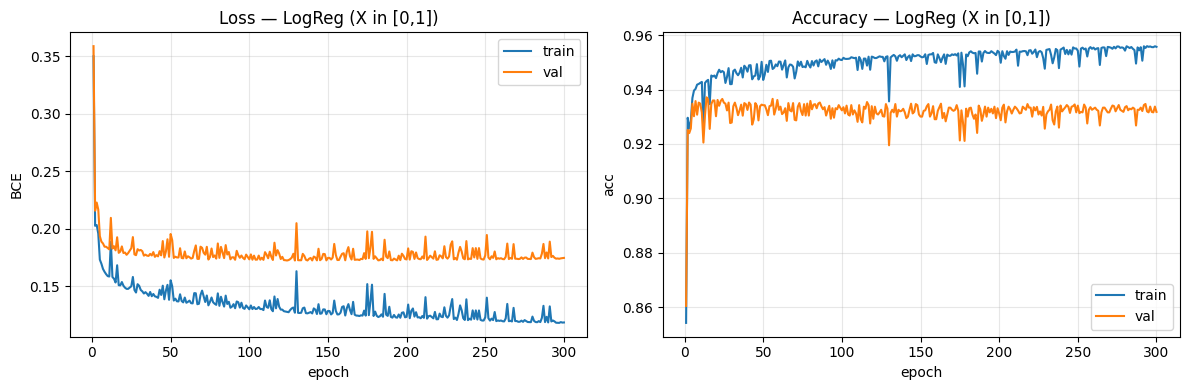

Epoch   1 | train loss 4.0060 acc 0.6985 | val loss 4.0464 acc 0.6993
Epoch   5 | train loss 0.9953 acc 0.9258 | val loss 1.0864 acc 0.9226
Epoch  10 | train loss 0.6682 acc 0.9432 | val loss 0.8531 acc 0.9333
Epoch  15 | train loss 0.6431 acc 0.9448 | val loss 0.8464 acc 0.9354
Epoch  20 | train loss 4.4793 acc 0.7015 | val loss 4.5584 acc 0.6973
Epoch  25 | train loss 0.7998 acc 0.9341 | val loss 0.9872 acc 0.9255
Epoch  30 | train loss 1.7894 acc 0.8537 | val loss 1.8418 acc 0.8504
Epoch  35 | train loss 0.6146 acc 0.9483 | val loss 0.8427 acc 0.9349
Epoch  40 | train loss 0.7033 acc 0.9360 | val loss 0.9508 acc 0.9211
Epoch  45 | train loss 1.4514 acc 0.8784 | val loss 1.5464 acc 0.8748
Epoch  50 | train loss 0.6878 acc 0.9424 | val loss 0.9298 acc 0.9302
Epoch  55 | train loss 0.5963 acc 0.9471 | val loss 0.8615 acc 0.9348
Epoch  60 | train loss 0.6542 acc 0.9407 | val loss 0.9235 acc 0.9238
Epoch  65 | train loss 2.1686 acc 0.8288 | val loss 2.2150 acc 0.8270
Epoch  70 | train lo

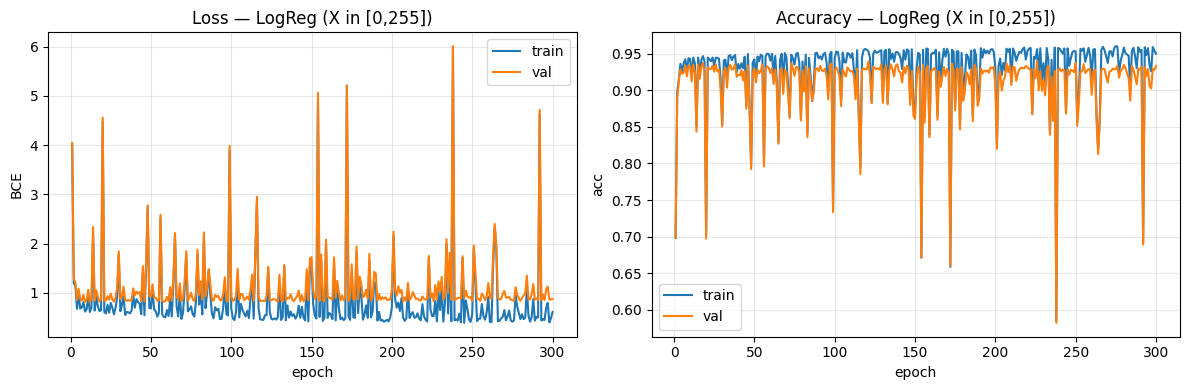

In [ ]:
# Train on normalized [0,1]
EPOCHS = 300
W_norm, b_norm, hist_norm = train_logreg_manual(
    Xn_train, y_train, Xn_val, y_val,
    lr=0.2, epochs=EPOCHS, batch_size=256, weight_scale=0.01
)
plot_history(hist_norm, title='LogReg (X in [0,1])')

# Train on raw-like [0,255] (usually needs much smaller lr)
W_raw, b_raw, hist_raw = train_logreg_manual(
    Xraw_train, y_train, Xraw_val, y_val,
    lr=1e-4, epochs=EPOCHS, batch_size=256, weight_scale=0.001
)
plot_history(hist_raw, title='LogReg (X in [0,255])')

### Task 1 — Krótkie wyjaśnienie (wymagane)

- **Dlaczego logistic regression?** Modeluje prawdopodobieństwo klasy $P(y=1\mid x)$ jako funkcję liniową cech (logit) przekształconą przez sigmoida; to klasyczny, prosty baseline do klasyfikacji binarnej.
- **Dlaczego sigmoid?** Mapuje logity $z\in\mathbb{R}$ do przedziału $(0,1)$, więc wynik można interpretować jako prawdopodobieństwo.
- **Skąd $\partial L/\partial z = \hat y - y$?** Dla $\hat y=\sigma(z)$ i BCE, po złożeniu pochodnych (łańcuch: BCE → sigmoid → logit) wyrazy się upraszczają i zostaje różnica predykcji i etykiety.
- **Dlaczego bez autograd?** Dla tego modelu mamy jawne wzory na gradienty $W,b$, więc możemy wykonać aktualizacje gradient descent ręcznie na tensorach.


# Task 2 — Logistic Regression: Manual Gradients vs Autograd (2 pts)

In this task you will verify your manual gradient calculations.

## Requirements

Using the **same dataset** and **same model**, compare:

* manual gradient computation,
* autograd gradient computation.

### Steps


1. Pick one mini-batch or a small subset of training data.
2. Compute:
   * manual $\frac{\partial L}{\partial W}$ and $\frac{\partial L}{\partial b}$,
   * autograd versions using `requires_grad=True` and `loss.backward()`.
3. Compare the values numerically.

You may report:

$$
\left\| \nabla_W^{\text{manual}} - \nabla_W^{\text{autograd}} \right\|
$$

and similarly for $b$.

## Required Explanation (Markdown)

Discuss:

* why the two gradients should match,
* possible reasons for small numerical differences,
* why checking gradients is useful when implementing models from scratch.


---

In [ ]:
# === Task 2: Manual gradients vs Autograd gradients ===
# We'll compare on ONE minibatch using the normalized input version.
batch_size = 128
ds_small = TensorDataset(Xn_train, y_train)
dl_small = DataLoader(ds_small, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(SEED))
xb, yb = next(iter(dl_small))
xb = xb.to(device)
yb = yb.to(device)

# Initialize same parameters for both computations
d = xb.shape[1]
g_cpu = torch.Generator().manual_seed(SEED)
W0 = (0.01 * torch.randn(d, 1, generator=g_cpu)).to(device)
b0 = torch.zeros(1, device=device)

# --- Manual gradients ---
z = xb @ W0 + b0
y_hat = sigmoid(z)
loss = bce_loss(y_hat, yb)
dL_dz = (y_hat - yb)
dW_manual = (xb.T @ dL_dz) / xb.shape[0]
db_manual = dL_dz.mean()

# --- Autograd gradients ---
W_ag = W0.clone().detach().requires_grad_(True)
b_ag = b0.clone().detach().requires_grad_(True)
z_ag = xb @ W_ag + b_ag
y_hat_ag = sigmoid(z_ag)
loss_ag = bce_loss(y_hat_ag, yb)
loss_ag.backward()
dW_auto = W_ag.grad.detach()
db_auto = b_ag.grad.detach()

# Compare
diff_W = torch.norm(dW_manual - dW_auto).item()
diff_b = torch.abs(db_manual - db_auto).item()
rel_W = diff_W / (torch.norm(dW_auto).item() + 1e-12)
rel_b = diff_b / (torch.abs(db_auto).item() + 1e-12)

print('Loss manual:', float(loss.item()), ' Loss autograd:', float(loss_ag.item()))
print('||dW_manual - dW_auto||:', diff_W, '  relative:', rel_W)
print('|db_manual - db_auto|   :', diff_b, '  relative:', rel_b)

Loss manual: 0.7224422693252563  Loss autograd: 0.7224422693252563
||dW_manual - dW_auto||: 1.3962332445771608e-07   relative: 6.902585472953861e-08
|db_manual - db_auto|   : 7.450580596923828e-09   relative: 8.86176479908612e-08


### Task 2 — Wyjaśnienie (wymagane)

- Gradienty powinny się zgadzać, bo autograd liczy te same pochodne (tylko automatycznie), a my użyliśmy poprawnych wzorów analitycznych.
- Małe różnice numeryczne mogą wynikać z: ograniczonej precyzji float, `clamp` w BCE (ochrona przed `log(0)`), oraz kolejności operacji (asocjatywność w arytmetyce zmiennoprzecinkowej).
- Taki test jest bardzo przydatny, bo pozwala szybko wykryć błąd w ręcznie wyprowadzonych pochodnych lub w implementacji forward/loss.


# Task 3 — MLP with 1 Hidden Layer (3 pts)

Now move from logistic regression to a neural network with one hidden layer.

Use the model

$$
a^{(0)} = x
$$

$$
z^{(1)} = a^{(0)} (W^{(1)})^T + b^{(1)}
$$

$$
a^{(1)} = g(z^{(1)})
$$

$$
z^{(2)} = a^{(1)} (W^{(2)})^T + b^{(2)}
$$

$$
\hat{y} = \sigma(z^{(2)})
$$

Choose a hidden activation such as $\tanh$ (see @[https://en.wikipedia.org/wiki/Hyperbolic_functions](mention://18b8a955-f332-42d0-8488-eb90b2ab27c6/url/4bf2f413-aea3-4855-8082-c1d3ade4b321) )

## Requirements


1. Implement all parameters manually as tensors:
   * $$
     W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}
     $$
2. Implement the forward pass manually.
3. Use manual binary cross-entropy.
4. Use autograd for gradients:
   * call `loss.backward()`,
   * update parameters manually inside `torch.no_grad()`.
5. Train for at least **100 epochs**.
6. Report training and validation:
   * loss,
   * accuracy.

## Plots

Plot:

* training loss vs epoch,
* validation loss vs epoch,
* training accuracy vs epoch,
* validation accuracy vs epoch.

## Required Explanation (Markdown)

Explain:

* why an MLP can model more complex decision boundaries than logistic regression,
* the role of the hidden activation function,
* why we still need a sigmoid in the output layer.


---

Epoch   1 | train loss 0.2257 acc 0.9103 | val loss 0.2395 acc 0.9081
Epoch   2 | train loss 0.1813 acc 0.9349 | val loss 0.1963 acc 0.9297
Epoch   5 | train loss 0.1816 acc 0.9276 | val loss 0.1992 acc 0.9230
Epoch  10 | train loss 0.2108 acc 0.9085 | val loss 0.2309 acc 0.9060
Epoch  20 | train loss 0.1214 acc 0.9547 | val loss 0.1470 acc 0.9418
Epoch  50 | train loss 0.0818 acc 0.9688 | val loss 0.1173 acc 0.9562
Epoch 100 | train loss 0.0670 acc 0.9738 | val loss 0.1287 acc 0.9529


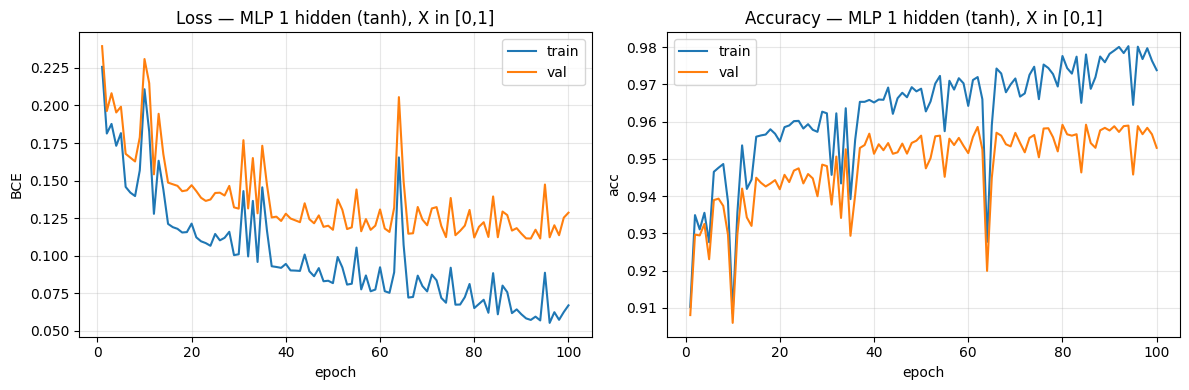

In [ ]:
# === Task 3: MLP with 1 hidden layer (manual forward, autograd grads, manual updates) ===
def init_mlp1(d_in, h1, weight_scale=0.05):
    # Init on CPU for reproducibility; then move to CUDA if available.
    g = torch.Generator().manual_seed(SEED)
    W1 = (weight_scale * torch.randn(h1, d_in, generator=g)).to(device).requires_grad_(True)
    b1 = torch.zeros(h1, device=device, requires_grad=True)
    W2 = (weight_scale * torch.randn(1, h1, generator=g)).to(device).requires_grad_(True)
    b2 = torch.zeros(1, device=device, requires_grad=True)
    return [W1, b1, W2, b2]

def forward_mlp1(X, params):
    W1, b1, W2, b2 = params
    z1 = X @ W1.T + b1  # (N,h1)
    a1 = torch.tanh(z1)
    z2 = a1 @ W2.T + b2  # (N,1)
    y_hat = sigmoid(z2)
    return y_hat

@torch.no_grad()
def eval_mlp1(X, y, params, batch_size=512):
    ds = TensorDataset(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    losses, accs = [], []
    for xb, yb in dl:
        xb = xb.to(device)
        yb = yb.to(device)
        y_hat = forward_mlp1(xb, params)
        losses.append(bce_loss(y_hat, yb).item())
        accs.append(accuracy(y_hat, yb).item())
    return float(np.mean(losses)), float(np.mean(accs))

def train_mlp1(X_train, y_train, X_val, y_val, h1=128, lr=0.1, epochs=100, batch_size=256, weight_scale=0.05):
    d_in = X_train.shape[1]
    params = init_mlp1(d_in, h1=h1, weight_scale=weight_scale)
    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(SEED))
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            y_hat = forward_mlp1(xb, params)
            loss = bce_loss(y_hat, yb)
            loss.backward()

            with torch.no_grad():
                for p in params:
                    p -= lr * p.grad
                    p.grad.zero_()

        tr_loss, tr_acc = eval_mlp1(X_train, y_train, params)
        va_loss, va_acc = eval_mlp1(X_val, y_val, params)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)
        if epoch in {1, 2, 5, 10, 20, 50, 100} or epoch == epochs:
            print(f"Epoch {epoch:3d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    return params, hist

mlp1_params, mlp1_hist = train_mlp1(Xn_train, y_train, Xn_val, y_val, h1=128, lr=0.2, epochs=100, batch_size=256)
plot_history(mlp1_hist, title='MLP 1 hidden (tanh), X in [0,1]')

### Task 3 — Wyjaśnienie (wymagane)

- MLP potrafi modelować nieliniowe granice decyzyjne dzięki warstwie ukrytej i nieliniowej aktywacji ($\tanh$), czego logistic regression (liniowy logit) nie umie.
- Aktywacja ukryta wprowadza nieliniowość i pozwala budować bogatsze reprezentacje cech.
- Sigmoid na wyjściu nadal jest potrzebny, bo chcemy prawdopodobieństwo klasy dodatniej $(0,1)$ i używamy BCE.


# Task 4 — MLP with 2+ Hidden Layers (2 pts)

Extend the previous model to **two (or more) hidden layers**.

Example architecture:

$$
a^{(0)} = x
$$

$$
z^{(1)} = a^{(0)} (W^{(1)})^T + b^{(1)}, \qquad a^{(1)} = g(z^{(1)})
$$

$$
z^{(2)} = a^{(1)} (W^{(2)})^T + b^{(2)}, \qquad a^{(2)} = g(z^{(2)})
$$

$$
z^{(3)} = a^{(2)} (W^{(3)})^T + b^{(3)}, \qquad \hat{y} = \sigma(z^{(3)})
$$

## Requirements


1. Implement a 2-hidden-layer MLP manually.
2. Train it on the same binary dataset.
3. Compare its performance with:
   * logistic regression,
   * 1-hidden-layer MLP.

## Required Comparison

Report for all three models:

* final train loss,
* final validation loss,
* final train accuracy,
* final validation accuracy.

## Required Explanation (Markdown)

Discuss:

* whether deeper models improved performance,
* whether the extra hidden layer was helpful,
* why a deeper model may help or may fail to help on this binary task.

Epoch   1 | train loss 0.2619 acc 0.8820 | val loss 0.2746 acc 0.8777
Epoch   2 | train loss 0.1873 acc 0.9315 | val loss 0.2024 acc 0.9289
Epoch   5 | train loss 0.1949 acc 0.9200 | val loss 0.2126 acc 0.9139
Epoch  10 | train loss 0.2143 acc 0.9057 | val loss 0.2343 acc 0.9054
Epoch  20 | train loss 0.1204 acc 0.9549 | val loss 0.1459 acc 0.9434
Epoch  50 | train loss 0.0801 acc 0.9699 | val loss 0.1171 acc 0.9541
Epoch 100 | train loss 0.0655 acc 0.9740 | val loss 0.1352 acc 0.9543


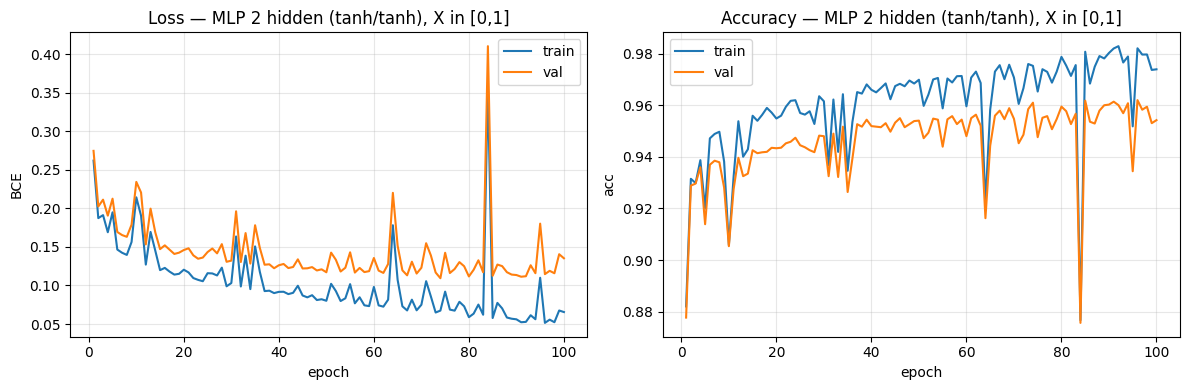

Model | train_loss | val_loss | train_acc | val_acc
LogReg |    0.1184 |   0.1746 |    0.9558 |  0.9318
MLP-1  |    0.0670 |   0.1287 |    0.9738 |  0.9529
MLP-2  |    0.0655 |   0.1352 |    0.9740 |  0.9543


In [ ]:
# === Task 4: MLP with 2 hidden layers (manual forward, autograd grads, manual updates) ===
def init_mlp2(d_in, h1, h2, weight_scale=0.05):
    # Init on CPU for reproducibility; then move to CUDA if available.
    g = torch.Generator().manual_seed(SEED)
    W1 = (weight_scale * torch.randn(h1, d_in, generator=g)).to(device).requires_grad_(True)
    b1 = torch.zeros(h1, device=device, requires_grad=True)
    W2 = (weight_scale * torch.randn(h2, h1, generator=g)).to(device).requires_grad_(True)
    b2 = torch.zeros(h2, device=device, requires_grad=True)
    W3 = (weight_scale * torch.randn(1, h2, generator=g)).to(device).requires_grad_(True)
    b3 = torch.zeros(1, device=device, requires_grad=True)
    return [W1, b1, W2, b2, W3, b3]

def forward_mlp2(X, params):
    W1, b1, W2, b2, W3, b3 = params
    z1 = X @ W1.T + b1
    a1 = torch.tanh(z1)
    z2 = a1 @ W2.T + b2
    a2 = torch.tanh(z2)
    z3 = a2 @ W3.T + b3
    y_hat = sigmoid(z3)
    return y_hat

@torch.no_grad()
def eval_mlp2(X, y, params, batch_size=512):
    ds = TensorDataset(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    losses, accs = [], []
    for xb, yb in dl:
        xb = xb.to(device)
        yb = yb.to(device)
        y_hat = forward_mlp2(xb, params)
        losses.append(bce_loss(y_hat, yb).item())
        accs.append(accuracy(y_hat, yb).item())
    return float(np.mean(losses)), float(np.mean(accs))

def train_mlp2(X_train, y_train, X_val, y_val, h1=128, h2=64, lr=0.1, epochs=100, batch_size=256, weight_scale=0.05):
    d_in = X_train.shape[1]
    params = init_mlp2(d_in, h1=h1, h2=h2, weight_scale=weight_scale)
    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(SEED))
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)
            y_hat = forward_mlp2(xb, params)
            loss = bce_loss(y_hat, yb)
            loss.backward()

            with torch.no_grad():
                for p in params:
                    p -= lr * p.grad
                    p.grad.zero_()

        tr_loss, tr_acc = eval_mlp2(X_train, y_train, params)
        va_loss, va_acc = eval_mlp2(X_val, y_val, params)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)
        if epoch in {1, 2, 5, 10, 20, 50, 100} or epoch == epochs:
            print(f"Epoch {epoch:3d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    return params, hist

mlp2_params, mlp2_hist = train_mlp2(Xn_train, y_train, Xn_val, y_val, h1=128, h2=64, lr=0.15, epochs=100, batch_size=256)
plot_history(mlp2_hist, title='MLP 2 hidden (tanh/tanh), X in [0,1]')

# === Required comparison across 3 models ===
final_metrics = []

# Logistic regression (normalized) final
final_metrics.append(('LogReg', hist_norm['train_loss'][-1], hist_norm['val_loss'][-1], hist_norm['train_acc'][-1], hist_norm['val_acc'][-1]))
final_metrics.append(('MLP-1', mlp1_hist['train_loss'][-1], mlp1_hist['val_loss'][-1], mlp1_hist['train_acc'][-1], mlp1_hist['val_acc'][-1]))
final_metrics.append(('MLP-2', mlp2_hist['train_loss'][-1], mlp2_hist['val_loss'][-1], mlp2_hist['train_acc'][-1], mlp2_hist['val_acc'][-1]))

print('Model | train_loss | val_loss | train_acc | val_acc')
for name, trl, val, tra, vaa in final_metrics:
    print(f"{name:6s} | {trl:9.4f} | {val:8.4f} | {tra:9.4f} | {vaa:7.4f}")

### Task 4 — Wyjaśnienie (wymagane)

- Głębszy model (2 warstwy ukryte) ma większą pojemność i może lepiej dopasować nieliniowości.
- Dodatkowa warstwa bywa pomocna, ale nie zawsze: przy zbyt dużej pojemności i prostym zadaniu może łatwo przeuczyć się (overfitting) albo trenować się trudniej bez strojenia hiperparametrów.
- W tym zadaniu porównanie metryk walidacyjnych (loss/accuracy) pokazuje, czy dodatkowa głębokość realnie pomaga na binarnej wersji Fashion-MNIST.